In [1]:
#%%
# -*- coding: utf-8 -*-
"""
Created on Thu Jul 15 15:34:27 2021

@author: hasan
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
#%%
df = pd.read_csv('/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/labels_updated.csv')

In [2]:
male_norm = df.query('gender=="male" and label=="normal"')
male_abnm = df.query('gender=="male" and label=="abnormal"')
female_norm = df.query('gender=="female" and label=="normal"')
female_abnm = df.query('gender=="female" and label=="abnormal"')
n_bins = 21
d_labels = ['Normal', 'Abnormal']

'''-------------------Calculate Stats-------------------'''
mean_age = df.groupby(['gender']).mean()
std_age = df.groupby(['gender']).std()

mean_age_male = mean_age.loc['male']['age']
std_age_male = std_age.loc['male']['age']
n_male = len(male_norm) + len(male_abnm)
p_male_norm = (len(male_norm)/n_male)*100
p_male_abnm = 100 - p_male_norm

mean_age_female = mean_age.loc['female']['age']
std_age_female = std_age.loc['female']['age']
n_female = len(female_norm) + len(female_abnm)
p_female_norm = (len(female_norm)/n_female)*100
p_female_abnm = 100 - p_female_norm

p_male = (n_male/(n_male + n_female))*100
p_female = 100 - p_male
#%%

/tmp/ipykernel_488712/2871670331.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_age = df.groupby(['gender']).mean()
/tmp/ipykernel_488712/2871670331.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  std_age = df.groupby(['gender']).std()


[  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100.]


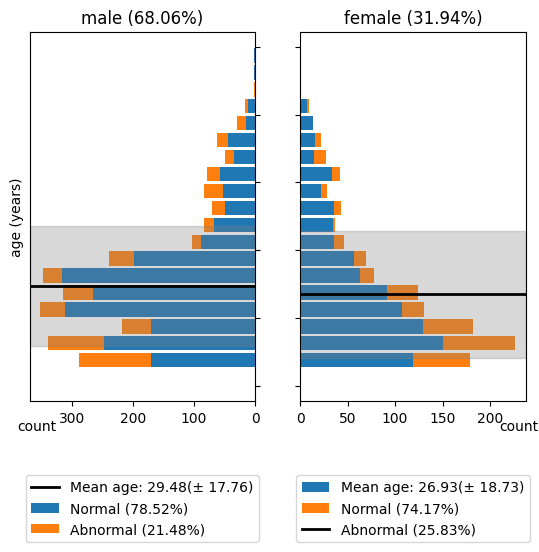

In [3]:
'''-------------------Plot Histograms------------------'''
bin_edges = np.linspace(start=0, stop = 100, num = n_bins,
                         endpoint = True)
print(bin_edges)
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.hist([male_norm.age, male_abnm.age], bins=bin_edges,
           rwidth=0.85,  orientation='horizontal', stacked=True)
ax1.invert_xaxis()
ax1.yaxis.tick_right()
ax1.set_title(f'male ({p_male:0.2f}%)')
ax1.set_xlabel('count')
ax1.xaxis.set_label_coords(0.03, -0.05)
ax1.set_ylabel('age (years)')
ax2.hist([female_norm.age, female_abnm.age], bins=bin_edges,
           rwidth=0.85, orientation='horizontal', stacked=True, label=d_labels)
ax2.set_title(f'female ({p_female:0.2f}%)')
ax2.set_xlabel('count')
ax2.xaxis.set_label_coords(0.97, -0.05)

'''-----------------Center Align yticklabels-------------'''
y = [0, 20, 40, 60, 80, 100]
ylbls = y
ax1.set(yticks=y, yticklabels=[])
for ycoord, ylbl in zip(y, ylbls):
    ax1.annotate(ylbl, (0.51, ycoord), xycoords=('figure fraction', 'data'),
                     ha='center', va='center')

'''-----------------Plot Mean line & Std-Dev ---------------------'''
xLims = ax1.get_xlim()
ax1.plot(xLims, [mean_age_male, mean_age_male], 'k-', lw=2)
ax1.legend([f'Mean age: {mean_age_male:.2f}(\u00B1 {std_age_male:.2f})',
             f'Normal ({p_male_norm:.2f}%)',
             f'Abnormal ({p_male_abnm:.2f}%)'],
             loc='lower center',  bbox_to_anchor=(0.5,-0.4))
'''(Command below) Since ax1 goes from left-2-right, the (xy) coordinate
represents the bottom right corner of rect instead of the bottom left corner
in the Rectangle documentation'''
ax1.add_patch(Rectangle((0, mean_age_male - std_age_male),
                        xLims[0], 2*std_age_male, color="grey", alpha=0.3))
ax1.set_xlim(xLims) #Gets rids of empty space between rect and Figure end
xLims = ax2.get_xlim()
ax2.plot(xLims, [mean_age_female, mean_age_female], 'k-', lw=2)
ax2.legend([f'Mean age: {mean_age_female:.2f}(\u00B1 {std_age_female:.2f})',
             f'Normal ({p_female_norm:.2f}%)',
             f'Abnormal ({p_female_abnm:.2f}%)'],
             loc='lower center',  bbox_to_anchor=(0.5,-0.4))

ax2.add_patch(Rectangle((0, mean_age_female - std_age_female),
                        xLims[1], 2*std_age_female, color="grey", alpha=0.3))
ax2.set_xlim(xLims) #Gets rids of empty space between rect and Figure end
plt.show()
fig.savefig('PopPyramid_img.png', format='png', dpi=1200, bbox_inches='tight')

[  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100.]


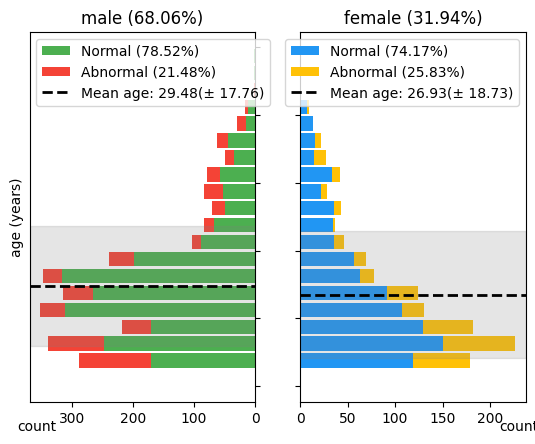

In [4]:
#%%
# Adjusting color palette
normal_color_male = '#4CAF50'  # Green for Normal (Male)
abnormal_color_male = '#F44336'  # Red for Abnormal (Male)
normal_color_female = '#2196F3'  # Blue for Normal (Female)
abnormal_color_female = '#FFC107'  # Yellow for Abnormal (Female)
mean_line_color = 'black'  # Black dashed line for the average


'''-------------------Plot Histograms------------------'''
bin_edges = np.linspace(start=0, stop = 100, num = n_bins,
                         endpoint = True)
print(bin_edges)
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.hist(
    [male_norm.age, male_abnm.age],
    bins=bin_edges,
    rwidth=0.85,
    orientation='horizontal',
    stacked=True,
    color=[normal_color_male, abnormal_color_male],
    label=['Normal', 'Abnormal']
)

ax1.invert_xaxis()
ax1.yaxis.tick_right()
ax1.set_title(f'male ({p_male:0.2f}%)')
ax1.set_xlabel('count')
ax1.xaxis.set_label_coords(0.03, -0.05)
ax1.set_ylabel('age (years)')


# Female Population Histogram
ax2.hist(
    [female_norm.age, female_abnm.age],
    bins=bin_edges,
    rwidth=0.85,
    orientation='horizontal',
    stacked=True,
    color=[normal_color_female, abnormal_color_female],
    label=['Normal', 'Abnormal']
)
ax2.set_title(f'female ({p_female:0.2f}%)')
ax2.set_xlabel('count')
ax2.xaxis.set_label_coords(0.97, -0.05)

'''-----------------Center Align yticklabels-------------'''
y = [0, 20, 40, 60, 80, 100]
ylbls = y
ax1.set(yticks=y, yticklabels=[])
for ycoord, ylbl in zip(y, ylbls):
    ax1.annotate(ylbl, (0.51, ycoord), xycoords=('figure fraction', 'data'),
                     ha='center', va='center')

'''-----------------Plot Mean line & Std-Dev ---------------------'''
# Add mean line and standard deviation shading
ax1.axhline(mean_age_male, color=mean_line_color, linestyle='--', linewidth=2)
ax1.add_patch(Rectangle(
    (0, mean_age_male - std_age_male), ax1.get_xlim()[0], 2 * std_age_male,
    color='gray', alpha=0.2
))
ax1.legend(
    [f'Normal ({p_male_norm:.2f}%)',
     f'Abnormal ({p_male_abnm:.2f}%)',
     f'Mean age: {mean_age_male:.2f}(\u00B1 {std_age_male:.2f})'],
    loc='upper left', fontsize=10
)

# Add mean line and standard deviation shading
ax2.axhline(mean_age_female, color=mean_line_color, linestyle='--', linewidth=2)
ax2.add_patch(Rectangle(
    (0, mean_age_female - std_age_female), ax2.get_xlim()[1], 2 * std_age_female,
    color='gray', alpha=0.2
))
ax2.legend(
    [f'Normal ({p_female_norm:.2f}%)',
     f'Abnormal ({p_female_abnm:.2f}%)',
     f'Mean age: {mean_age_female:.2f}(\u00B1 {std_age_female:.2f})'],
    loc='upper right', fontsize=10
)


plt.show()
fig.savefig('PopPyramid_img.png', format='png', dpi=1200, bbox_inches='tight')

#%%

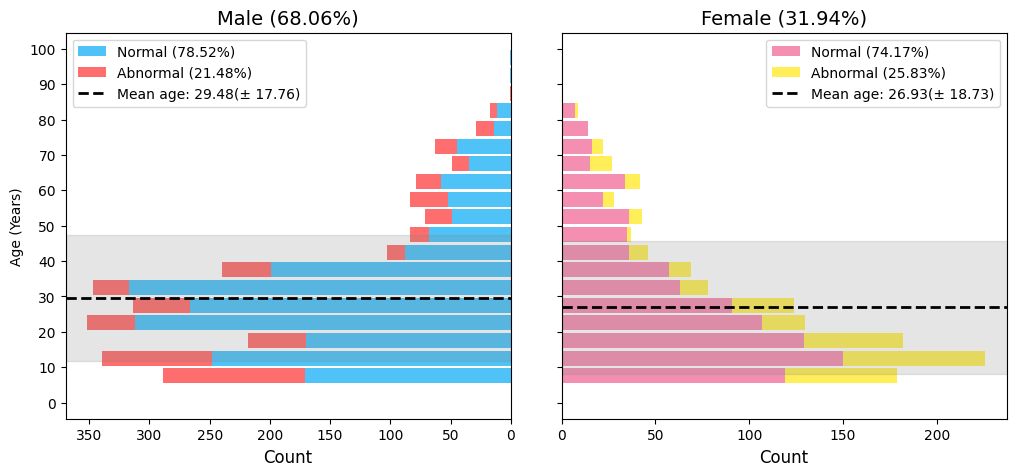

In [5]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Adjusting color palette
normal_color_male     = '#4FC3F7'   # Sky Blue
abnormal_color_male   = '#FF6E6E'   # Coral Red
normal_color_female   = '#F48FB1'   # Rose Pink
abnormal_color_female = '#FFEE58'   # Lemon Yellow
mean_line_color = 'black'  # Black dashed line for the average

# Define the bin edges
bin_edges = np.linspace(0, 100, n_bins)

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

# Set y-ticks for both diagrams
y_ticks = np.arange(0, 101, 10)

# Male Population Histogram
ax1.hist(
    [male_norm.age, male_abnm.age],
    bins=bin_edges,
    rwidth=0.85,
    orientation='horizontal',
    stacked=True,
    color=[normal_color_male, abnormal_color_male],
    label=['Normal', 'Abnormal']
)
ax1.invert_xaxis()
ax1.set_title(f'Male ({p_male:.2f}%)', fontsize=14)
ax1.set_xlabel('Count', fontsize=12)
ax1.set_ylabel('Age (Years)')
# Set the ticks and locations for ax1
# ax1.set(yticks=y, yticklabels=[])
# for ycoord, ylbl in zip(y, ylbls):
#     ax1.annotate(ylbl, (0.51, ycoord), xycoords=('figure fraction', 'data'),
#                      ha='center', va='center')

# Add mean line and standard deviation shading
ax1.axhline(mean_age_male, color=mean_line_color, linestyle='--', linewidth=2)
ax1.add_patch(Rectangle(
    (0, mean_age_male - std_age_male), ax1.get_xlim()[0], 2 * std_age_male,
    color='gray', alpha=0.2
))
ax1.legend(
    [f'Normal ({p_male_norm:.2f}%)',
     f'Abnormal ({p_male_abnm:.2f}%)',
     f'Mean age: {mean_age_male:.2f}(\u00B1 {std_age_male:.2f})'],
    loc='upper left', fontsize=10
)

# Female Population Histogram
ax2.hist(
    [female_norm.age, female_abnm.age],
    bins=bin_edges,
    rwidth=0.85,
    orientation='horizontal',
    stacked=True,
    color=[normal_color_female, abnormal_color_female],
    label=['Normal', 'Abnormal']
)
ax2.set_title(f'Female ({p_female:.2f}%)', fontsize=14)
ax2.set_xlabel('Count', fontsize=12)
ax2.set_yticks(y_ticks)
ax2.set_yticklabels(y_ticks, fontsize=10)  # Add ticks for female diagram

# Add mean line and standard deviation shading
ax2.axhline(mean_age_female, color=mean_line_color, linestyle='--', linewidth=2)
ax2.add_patch(Rectangle(
    (0, mean_age_female - std_age_female), ax2.get_xlim()[1], 2 * std_age_female,
    color='gray', alpha=0.2
))
ax2.legend(
    [f'Normal ({p_female_norm:.2f}%)',
     f'Abnormal ({p_female_abnm:.2f}%)',
     f'Mean age: {mean_age_female:.2f}(\u00B1 {std_age_female:.2f})'],
    loc='upper right', fontsize=10
)

# Add a title and adjust layout
# plt.suptitle('Population Pyramid by Gender and Age Group', fontsize=16)
fig.tight_layout(pad=3.0, rect=[0.05, 0.05, 0.95, 0.95])

# Save and display the plot
plt.show()
fig.savefig('gender_distribution_nmt_4k.png', format='png', dpi=300, bbox_inches='tight')

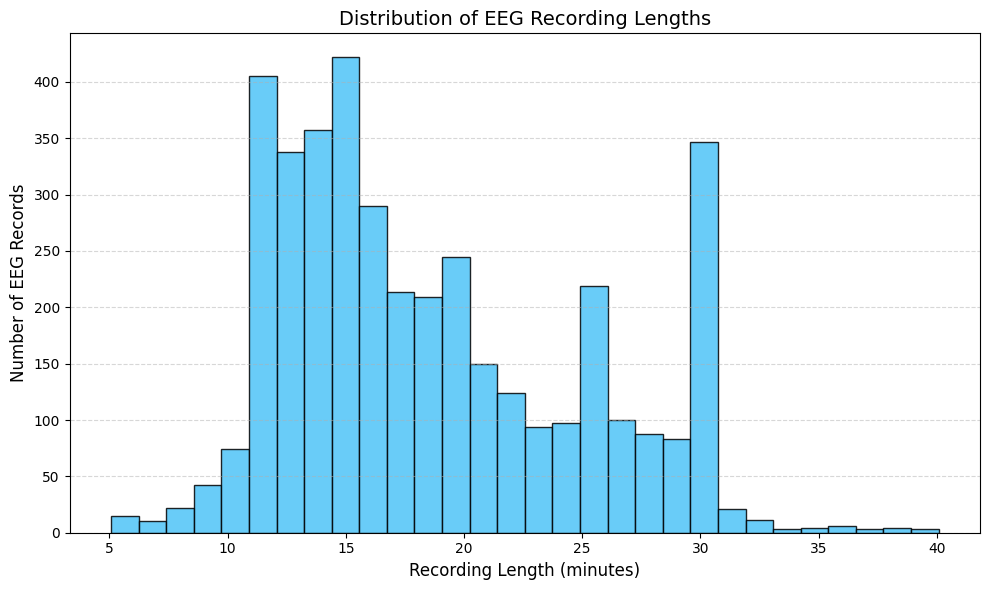

File list has been saved to 'file_list.xlsx'.


In [10]:

#%%
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data

df = pd.read_csv('/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/labels_updated.csv')
df.columns = df.columns.str.strip()

# Ensure recording length column is numeric and clean
df = df[pd.to_numeric(df["edf_length (minutes)"], errors='coerce').notna()]
df["edf_length (minutes)"] = df["edf_length (minutes)"].astype(float)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df["edf_length (minutes)"], bins=30, color="#4FC3F7", edgecolor='black', alpha=0.85)
plt.xlabel("Recording Length (minutes)", fontsize=12)
plt.ylabel("Number of EEG Records", fontsize=12)
plt.title("Distribution of EEG Recording Lengths", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the figure
plt.savefig("recording_duration_nmt_4k.png", dpi=300, bbox_inches='tight')
plt.show()

#%%
import os
import pandas as pd

def list_files_in_directory(directory, output_excel):
    # List to store file information
    file_data = []

    # Walk through the directory and its subdirectories
    for root, dirs,fs in os.walk(directory):
        print(root,dirs)
        for dir in dirs:
            print(dir)
            if(dir == "abnormal" or dir == "normal"):
                for root1, dirs1, files in os.walk(os.path.join(directory,dir)):
                    for file in files:
                        print(file)
                        file_data.append({"Folder": os.path.basename(dir), "File": file})

    # Create a DataFrame
    df = pd.DataFrame(file_data)

    # Save to Excel
    df.to_excel(output_excel, index=False)
    print(f"File list has been saved to '{output_excel}'.")

# Usage
directory_to_scan = "/Volumes/My Passport/datasets/EEG Datasets/[A] EEG Data Files/EDFv2/edfProcessed/"  # Replace with the path to your folder
output_excel_file = "file_list.xlsx"          # Name of the output Excel file

list_files_in_directory(directory_to_scan, output_excel_file)




In [ ]:
#%%
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example confusion matrices for three datasets
confusion_matrices = {
    "TUAB": np.array([[128, 8], [16, 93]]),
    "NMT": np.array([[79, 7], [9, 77]]),
    "NMT-4k": np.array([[334, 63], [53, 255]])
}

# Define class labels
class_labels = ["Normal", "Abnormal"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Color palette for heatmaps
cmap = sns.light_palette("navy", as_cmap=True)

# Plot each confusion matrix
for ax, (title, cm) in zip(axes, confusion_matrices.items()):
    if title == "TUAB":
        sns.heatmap(
            cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels,
            yticklabels=class_labels, ax=ax, annot_kws={"size": 40}  # Set annotation size
        )
    else:
        sns.heatmap(
            cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels,
            yticklabels=[], ax=ax, annot_kws={"size": 40}  # Set annotation size
        )
    ax.set_title(title, fontsize=25)  # Title font size
    if title == "NMT":
        ax.set_xlabel("Predicted labels", fontsize=20)  # X-axis label size
    if title == "TUAB":
        ax.set_ylabel("True labels", fontsize=20)  # Y-axis label size
    ax.tick_params(axis='both', which='major', labelsize=20)  # Tick label size

# Add colorbar to the right of all plots
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap), ax=axes, orientation='vertical', shrink=0.8, pad=0.02
)
cbar.set_label("Counts", fontsize=20)  # Colorbar label font size
cbar.ax.tick_params(labelsize=20)  # Colorbar tick font size

# Show the plot
plt.show()
fig.savefig('confusion_matrics.png', format='png', dpi=300, bbox_inches='tight')

13
13
13
13
13
13


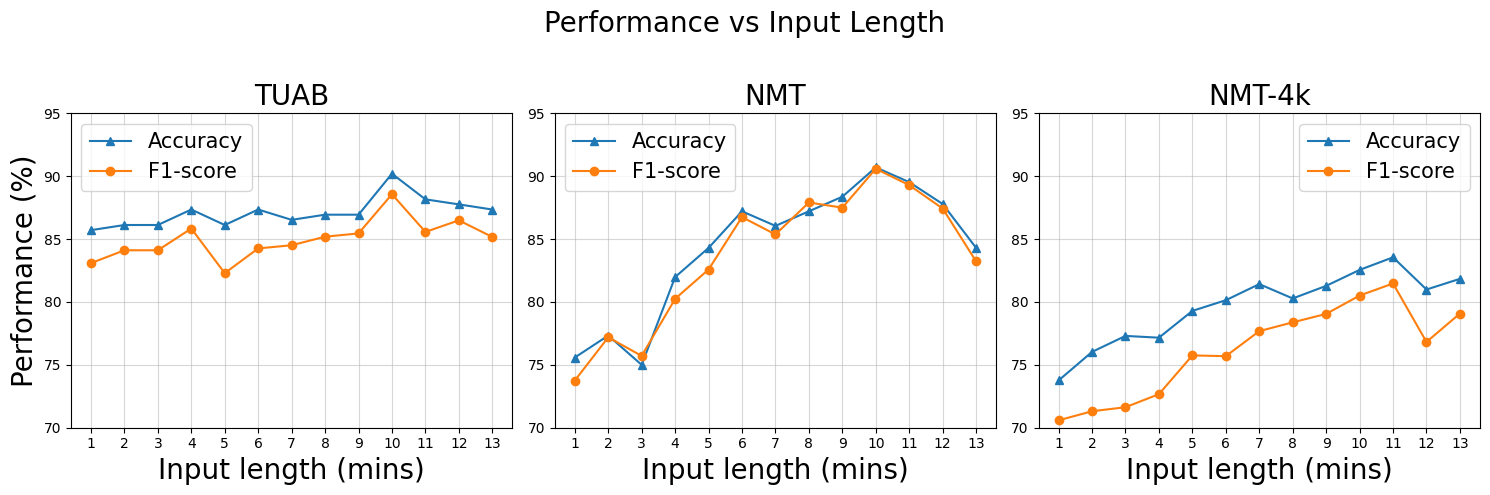

In [7]:
#%%
import matplotlib.pyplot as plt
import numpy as np

# Input lengths in minutes
input_lengths = np.arange(1, 14, 1)

# Accurate performance metrics for each dataset
# tuh_accuracy = [80, 82, 84, 86, 87, 88, 86]
# tuh_f1 = [78, 80, 82, 84, 85, 86, 84]

# tuh_accuracy = [82.61, 84.06, 85.14, 85.51, 86.59, 87.68, 86.23]
# tuh_f1 = [79.83, 81.67, 82.10, 82.46, 84.26, 86.72, 84.55]

tuh_accuracy = [85.71, 86.12, 86.12, 87.35, 86.12, 87.35, 86.53, 86.94, 86.94, 90.20, 88.16, 87.76, 87.35]
tuh_f1 = [83.09, 84.11, 84.11, 85.84, 82.29, 84.26, 84.51, 85.19, 85.45, 88.57, 85.57, 86.49, 85.17]
print(len(tuh_accuracy))
print(len(tuh_f1))

# nmt_accuracy = [74, 76, 78, 81, 83, 84, 84]
# nmt_f1 = [72, 74, 76, 80, 82, 83, 83]
# nmt_accuracy = [75.86, 75.86, 88.51, 91.38, 89.08, 91.95, 89.66]
# nmt_f1 = [73.75, 73.08, 87.80, 91.12, 89.39, 92.05, 89.41]
nmt_accuracy = [75.58, 77.33, 75, 81.98, 84.30, 87.21, 86.05, 87.21, 88.37, 90.70, 89.53, 87.79, 84.30]
nmt_f1 = [73.75, 77.19, 75.71, 80.25, 82.58, 86.75, 85.37, 87.91, 87.50, 90.59, 89.29, 87.43, 83.23]
print(len(nmt_accuracy))
print(len(nmt_f1))

# nmt_v2_accuracy = [74, 76, 79, 83, 84, 85, 84]
# nmt_v2_f1 = [72, 74, 77, 81, 83, 84, 83]
# nmt_v2_accuracy = [76.11, 81.12, 82.01, 83.48, 83.78, 86.73, 84.07]
# nmt_v2_f1 = [71.58, 78.23, 80.63, 83.13, 83.48, 86.73, 83.33]
# nmt_v2_accuracy = [75.58, 77.33, 75, 81.98, 84.30, 87.21, 86.05, 87.21, 88.37, 90.70, 89.53, 87.79, 84.30]
# nmt_v2_f1 = [73.75, 77.19, 75.71, 80.25, 82.58, 86.75, 85.37, 87.91, 87.50, 90.59, 89.29, 87.43, 83.23]

nmt_v2_accuracy = [73.76, 76.03, 77.30, 77.16, 79.29, 80.14, 81.42, 80.28, 81.28, 82.55, 83.55, 80.99, 81.84]
nmt_v2_f1 = [70.59, 71.31, 71.63, 72.67, 75.75, 75.69, 77.68, 78.38, 79.05, 80.51, 81.47, 76.82, 79.08]

print(len(nmt_v2_accuracy))
print(len(nmt_v2_f1))
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()  # Flatten for easier indexing

# Titles for subplots
titles = ['TUAB', 'NMT', 'NMT-4k']

# Data for plotting
datasets = [
    (tuh_accuracy, tuh_f1),
    (nmt_accuracy, nmt_f1),
    (nmt_v2_accuracy, nmt_v2_f1),
]

# Loop through datasets and plot
for i, (data, ax) in enumerate(zip(datasets, axes[:3])):

    accuracy, f1 = data
    ax.plot(input_lengths, accuracy, marker='^', label='Accuracy', linestyle='-', linewidth=1.5)
    ax.plot(input_lengths, f1, marker='o', label='F1-score', linestyle='-', linewidth=1.5)
    ax.set_title(titles[i], fontsize=20)
    ax.set_xlabel('Input length (mins)', fontsize=20)
    if(i == 0):
        ax.set_ylabel('Performance (%)', fontsize=20)
    ax.set_xticks(input_lengths)
    ax.set_ylim(70, 95)  # Adjust limits as per data
    ax.legend(fontsize=15)
    ax.grid(alpha=0.5)

# Hide the fourth subplot (bottom-right)
# axes[3].axis('off')

# Adjust layout and overall title
plt.suptitle('Performance vs Input Length', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title

# Show the plot
plt.show()
fig.savefig('input_lengths_performance.png', format='png', dpi=300, bbox_inches='tight')


In [ ]:

#%%
# Re-import necessary libraries after execution state reset
import numpy as np
import matplotlib.pyplot as plt

# Updated accuracies based on the provided data
accuracies = {
    "TUH": np.array([85.85, 87.26, 90.20, 88.68, 89.15, 87.74, 87.26, 85.78, 89.57, 86.73]),
    "NMT": np.array([87.67, 88.33, 90.70, 87.86, 90.07, 87.86, 90.07, 88.74, 88.30, 88.96]),
    # "NMT-4k": np.array([84.13, 86.72, 87.55, 84.13, 84.13, 84.81, 87.78, 82.22, 84.81, 85.56])
    "NMT-4k": np.array([79.13, 81.72, 82.55, 79.13, 79.13, 79.81, 82.78, 77.22, 79.81, 80.56])
}

# Calculate means and standard deviations
means = {model: np.mean(scores) for model, scores in accuracies.items()}
std_devs = {model: np.std(scores) for model, scores in accuracies.items()}

# Plotting the bar chart with adjusted width and increased font size
models = list(accuracies.keys())
x = np.arange(len(models))
mean_values = [means[model] for model in models]
std_values = [std_devs[model] for model in models]
# Adjusting the spacing between bars
bar_width = 0.7  # Adjust the width of bars
bar_spacing = 1.5  # Adjust the spacing between bars

# Plotting with adjusted bar spacing
plt.figure(figsize=(4, 3))
bars = plt.bar(x, mean_values, yerr=std_values, capsize=8, alpha=0.8, edgecolor="black",
               hatch=["/", "x", "o"], color="white", error_kw={"elinewidth": 1.5, "ecolor": "black"},
               width=bar_width)  # Adjusting bar width

# Formatting the plot
plt.xticks(x, models, fontsize=10)
plt.yticks(np.arange(0, 110, 10), fontsize=8)
plt.ylim(0, 100)
# plt.title("Standard Deviation", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=10)
plt.xlabel("Models", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Adjusting the spacing between bars
# plt.xlim(-0.5, len(x) - 0.5)  # Expanding the x-axis to create more space between bars

# Display the plot
plt.tight_layout()
plt.savefig('std_chart.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#%%
import matplotlib.pyplot as plt
import numpy as np

# Adjusted input lengths for the plot: 1, 3, 5, ..., 13 minutes
input_lengths_adjusted = np.arange(1, 14, 2)  # Input lengths in minutes (1, 3, 5, ..., 13)
accuracy_adjusted = [76.11, 81.12, 82.01, 83.48, 83.78, 86.73, 84.07]
f1_score_adjusted = [71.58, 78.23, 80.63, 83.13, 83.48, 86.73, 83.33]
# auc_adjusted = [75.97, 81.01, 81.95, 83.47, 83.77, 86.4, 84.04]

# Create the adjusted plot
plt.figure(figsize=(8, 4))
plt.plot(input_lengths_adjusted, accuracy_adjusted, marker='^', label='Accuracy')
plt.plot(input_lengths_adjusted, f1_score_adjusted, marker='d', label='F1-score', color='orange')
# plt.plot(input_lengths_adjusted, auc_adjusted, marker='o', label='AUC', color='gray')

# Add labels, title, and legend
plt.xlabel('Input length (mins)')
plt.ylabel('Performance (%)')
plt.title('Performance vs Input Length')
plt.xticks(input_lengths_adjusted)
plt.yticks(np.arange(70, 88, 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:

#%%
import matplotlib.pyplot as plt

# Insert your FPR and TPR arrays here
tuh_fpr = [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0074, 0.0074, 0.0074, 0.0074, 0.0074,
        0.0074, 0.0074, 0.0074, 0.0074, 0.0074, 0.0074, 0.0074, 0.0147, 0.0147,
        0.0147, 0.0147, 0.0147, 0.0147, 0.0147, 0.0147, 0.0147, 0.0147, 0.0147,
        0.0147, 0.0147, 0.0147, 0.0221, 0.0221, 0.0221, 0.0221, 0.0221, 0.0221,
        0.0221, 0.0221, 0.0221, 0.0221, 0.0294, 0.0294, 0.0294, 0.0294, 0.0368,
        0.0368, 0.0368, 0.0441, 0.0441, 0.0441, 0.0441, 0.0441, 0.0441, 0.0441,
        0.0441, 0.0441, 0.0441, 0.0515, 0.0515, 0.0515, 0.0588, 0.0588, 0.0588,
        0.0588, 0.0588, 0.0588, 0.0662, 0.0735, 0.0735, 0.0809, 0.0809, 0.0882,
        0.0956, 0.0956, 0.1029, 0.1103, 0.1176, 0.1250, 0.1250, 0.1324, 0.1397,
        0.1397, 0.1471, 0.1544, 0.1618, 0.1691, 0.1691, 0.1765, 0.1838, 0.1838,
        0.1912, 0.1985, 0.1985, 0.2059, 0.2132, 0.2206, 0.2279, 0.2353, 0.2426,
        0.2500, 0.2574, 0.2574, 0.2647, 0.2721, 0.2794, 0.2868, 0.2941, 0.3015,
        0.3015, 0.3015, 0.3088, 0.3162, 0.3235, 0.3309, 0.3309, 0.3382, 0.3456,
        0.3529, 0.3603, 0.3676, 0.3750, 0.3824, 0.3897, 0.3971, 0.3971, 0.4044,
        0.4118, 0.4191, 0.4265, 0.4338, 0.4412, 0.4485, 0.4485, 0.4485, 0.4559,
        0.4632, 0.4706, 0.4779, 0.4853, 0.4926, 0.5000, 0.5074, 0.5147, 0.5221,
        0.5294, 0.5368, 0.5441, 0.5515, 0.5588, 0.5662, 0.5735, 0.5809, 0.5882,
        0.5956, 0.6029, 0.6103, 0.6176, 0.6250, 0.6324, 0.6397, 0.6471, 0.6544,
        0.6618, 0.6691, 0.6765, 0.6838, 0.6912, 0.6985, 0.7059, 0.7132, 0.7206,
        0.7279, 0.7353, 0.7426, 0.7500, 0.7574, 0.7647, 0.7721, 0.7794, 0.7868,
        0.7941, 0.7941, 0.8015, 0.8088, 0.8162, 0.8235, 0.8309, 0.8382, 0.8456,
        0.8529, 0.8603, 0.8676, 0.8750, 0.8824, 0.8897, 0.8971, 0.9044, 0.9118,
        0.9191, 0.9265, 0.9338, 0.9412, 0.9485, 0.9559, 0.9632, 0.9706, 0.9779,
        0.9853, 0.9926, 1.0000]
tuh_tpr = [0.0000, 0.0092, 0.0183, 0.0275, 0.0367, 0.0459, 0.0550, 0.0642, 0.0734,
        0.0826, 0.0917, 0.1009, 0.1101, 0.1193, 0.1284, 0.1376, 0.1468, 0.1560,
        0.1651, 0.1743, 0.1835, 0.1927, 0.2018, 0.2110, 0.2202, 0.2294, 0.2385,
        0.2477, 0.2569, 0.2661, 0.2752, 0.2844, 0.2936, 0.3028, 0.3119, 0.3211,
        0.3303, 0.3394, 0.3486, 0.3578, 0.3578, 0.3670, 0.3761, 0.3853, 0.3945,
        0.4037, 0.4128, 0.4220, 0.4312, 0.4404, 0.4495, 0.4587, 0.4587, 0.4679,
        0.4771, 0.4862, 0.4954, 0.5046, 0.5138, 0.5229, 0.5321, 0.5413, 0.5505,
        0.5596, 0.5688, 0.5780, 0.5780, 0.5872, 0.5963, 0.6055, 0.6147, 0.6239,
        0.6330, 0.6422, 0.6514, 0.6606, 0.6606, 0.6697, 0.6789, 0.6881, 0.6881,
        0.6972, 0.7064, 0.7064, 0.7156, 0.7248, 0.7339, 0.7431, 0.7523, 0.7615,
        0.7706, 0.7798, 0.7890, 0.7890, 0.7982, 0.8073, 0.8073, 0.8165, 0.8257,
        0.8349, 0.8440, 0.8532, 0.8532, 0.8532, 0.8624, 0.8624, 0.8716, 0.8716,
        0.8716, 0.8807, 0.8807, 0.8807, 0.8807, 0.8807, 0.8899, 0.8899, 0.8899,
        0.8991, 0.8991, 0.8991, 0.8991, 0.8991, 0.9083, 0.9083, 0.9083, 0.9174,
        0.9174, 0.9174, 0.9266, 0.9266, 0.9266, 0.9266, 0.9266, 0.9266, 0.9266,
        0.9266, 0.9266, 0.9358, 0.9358, 0.9358, 0.9358, 0.9358, 0.9358, 0.9358,
        0.9450, 0.9541, 0.9541, 0.9541, 0.9541, 0.9541, 0.9633, 0.9633, 0.9633,
        0.9633, 0.9633, 0.9633, 0.9633, 0.9633, 0.9633, 0.9633, 0.9725, 0.9725,
        0.9725, 0.9725, 0.9725, 0.9725, 0.9725, 0.9725, 0.9817, 0.9908, 0.9908,
        0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908,
        0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908,
        0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908,
        0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908,
        0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908, 0.9908,
        0.9908, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000]
nmt_fpr = [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0116, 0.0116, 0.0116, 0.0116, 0.0116, 0.0116, 0.0116, 0.0116, 0.0116,
        0.0116, 0.0116, 0.0233, 0.0233, 0.0233, 0.0233, 0.0233, 0.0233, 0.0233,
        0.0349, 0.0349, 0.0349, 0.0349, 0.0349, 0.0349, 0.0349, 0.0465, 0.0465,
        0.0465, 0.0465, 0.0465, 0.0465, 0.0465, 0.0465, 0.0465, 0.0465, 0.0465,
        0.0465, 0.0465, 0.0581, 0.0581, 0.0581, 0.0581, 0.0581, 0.0581, 0.0581,
        0.0581, 0.0581, 0.0581, 0.0581, 0.0581, 0.0581, 0.0581, 0.0581, 0.0698,
        0.0814, 0.0814, 0.0814, 0.0814, 0.0814, 0.0930, 0.0930, 0.1047, 0.1163,
        0.1279, 0.1395, 0.1395, 0.1512, 0.1628, 0.1744, 0.1860, 0.1860, 0.1860,
        0.1977, 0.2093, 0.2209, 0.2209, 0.2326, 0.2442, 0.2558, 0.2558, 0.2674,
        0.2791, 0.2791, 0.2907, 0.3023, 0.3140, 0.3256, 0.3372, 0.3488, 0.3605,
        0.3721, 0.3837, 0.3953, 0.4070, 0.4186, 0.4186, 0.4302, 0.4419, 0.4535,
        0.4651, 0.4767, 0.4884, 0.5000, 0.5116, 0.5233, 0.5349, 0.5465, 0.5581,
        0.5698, 0.5814, 0.5930, 0.6047, 0.6163, 0.6279, 0.6395, 0.6512, 0.6628,
        0.6744, 0.6860, 0.6977, 0.7093, 0.7209, 0.7326, 0.7442, 0.7558, 0.7674,
        0.7791, 0.7907, 0.8023, 0.8140, 0.8256, 0.8372, 0.8488, 0.8605, 0.8721,
        0.8837, 0.8953, 0.9070, 0.9186, 0.9302, 0.9419, 0.9535, 0.9651, 0.9767,
        0.9884, 1.0000]
nmt_tpr = [0.0000, 0.0116, 0.0233, 0.0349, 0.0465, 0.0581, 0.0698, 0.0814, 0.0930,
        0.1047, 0.1163, 0.1279, 0.1395, 0.1512, 0.1628, 0.1744, 0.1860, 0.1977,
        0.2093, 0.2209, 0.2326, 0.2442, 0.2558, 0.2674, 0.2791, 0.2907, 0.3023,
        0.3023, 0.3140, 0.3256, 0.3372, 0.3488, 0.3605, 0.3721, 0.3837, 0.3953,
        0.4070, 0.4186, 0.4186, 0.4302, 0.4419, 0.4535, 0.4651, 0.4767, 0.4884,
        0.4884, 0.5000, 0.5116, 0.5233, 0.5349, 0.5465, 0.5581, 0.5581, 0.5698,
        0.5814, 0.5930, 0.6047, 0.6163, 0.6279, 0.6395, 0.6512, 0.6628, 0.6744,
        0.6860, 0.6977, 0.6977, 0.7093, 0.7209, 0.7326, 0.7442, 0.7558, 0.7674,
        0.7791, 0.7907, 0.8023, 0.8140, 0.8256, 0.8372, 0.8488, 0.8605, 0.8605,
        0.8605, 0.8721, 0.8837, 0.8953, 0.9070, 0.9070, 0.9186, 0.9186, 0.9186,
        0.9186, 0.9186, 0.9302, 0.9302, 0.9302, 0.9302, 0.9302, 0.9419, 0.9535,
        0.9535, 0.9535, 0.9535, 0.9651, 0.9651, 0.9651, 0.9651, 0.9767, 0.9767,
        0.9767, 0.9884, 0.9884, 0.9884, 0.9884, 0.9884, 0.9884, 0.9884, 0.9884,
        0.9884, 0.9884, 0.9884, 0.9884, 0.9884, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000]
nmt4k_fpr = [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0025, 0.0025, 0.0025, 0.0025,
        0.0050, 0.0050, 0.0050, 0.0050, 0.0050, 0.0076, 0.0076, 0.0076, 0.0076,
        0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076,
        0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076, 0.0101, 0.0101,
        0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101, 0.0101,
        0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126,
        0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0126, 0.0151, 0.0151,
        0.0151, 0.0151, 0.0151, 0.0151, 0.0176, 0.0176, 0.0202, 0.0202, 0.0227,
        0.0227, 0.0227, 0.0227, 0.0227, 0.0227, 0.0227, 0.0227, 0.0227, 0.0227,
        0.0252, 0.0277, 0.0277, 0.0302, 0.0302, 0.0302, 0.0302, 0.0302, 0.0302,
        0.0327, 0.0327, 0.0327, 0.0327, 0.0327, 0.0327, 0.0353, 0.0353, 0.0353,
        0.0353, 0.0378, 0.0403, 0.0403, 0.0403, 0.0403, 0.0428, 0.0428, 0.0428,
        0.0428, 0.0453, 0.0453, 0.0453, 0.0453, 0.0453, 0.0453, 0.0453, 0.0479,
        0.0479, 0.0504, 0.0504, 0.0504, 0.0504, 0.0504, 0.0529, 0.0529, 0.0529,
        0.0529, 0.0554, 0.0579, 0.0579, 0.0579, 0.0605, 0.0605, 0.0605, 0.0605,
        0.0605, 0.0605, 0.0605, 0.0605, 0.0630, 0.0630, 0.0630, 0.0630, 0.0655,
        0.0655, 0.0655, 0.0680, 0.0680, 0.0680, 0.0680, 0.0680, 0.0680, 0.0680,
        0.0705, 0.0705, 0.0705, 0.0730, 0.0730, 0.0730, 0.0730, 0.0730, 0.0730,
        0.0730, 0.0730, 0.0730, 0.0730, 0.0730, 0.0730, 0.0730, 0.0730, 0.0730,
        0.0756, 0.0756, 0.0781, 0.0781, 0.0781, 0.0781, 0.0781, 0.0781, 0.0781,
        0.0806, 0.0831, 0.0856, 0.0882, 0.0907, 0.0907, 0.0932, 0.0932, 0.0957,
        0.0957, 0.0957, 0.0957, 0.0982, 0.0982, 0.0982, 0.1008, 0.1008, 0.1008,
        0.1033, 0.1033, 0.1033, 0.1058, 0.1083, 0.1083, 0.1083, 0.1083, 0.1083,
        0.1083, 0.1083, 0.1083, 0.1083, 0.1108, 0.1108, 0.1134, 0.1134, 0.1134,
        0.1134, 0.1159, 0.1159, 0.1159, 0.1184, 0.1184, 0.1184, 0.1184, 0.1209,
        0.1209, 0.1209, 0.1209, 0.1234, 0.1234, 0.1234, 0.1259, 0.1259, 0.1259,
        0.1285, 0.1285, 0.1285, 0.1285, 0.1285, 0.1310, 0.1310, 0.1335, 0.1335,
        0.1335, 0.1335, 0.1335, 0.1360, 0.1360, 0.1360, 0.1360, 0.1385, 0.1385,
        0.1385, 0.1385, 0.1385, 0.1385, 0.1411, 0.1411, 0.1411, 0.1436, 0.1436,
        0.1436, 0.1461, 0.1461, 0.1461, 0.1486, 0.1511, 0.1511, 0.1537, 0.1562,
        0.1562, 0.1562, 0.1562, 0.1587, 0.1587, 0.1612, 0.1612, 0.1612, 0.1612,
        0.1612, 0.1612, 0.1637, 0.1637, 0.1637, 0.1637, 0.1637, 0.1662, 0.1688,
        0.1713, 0.1738, 0.1763, 0.1788, 0.1788, 0.1814, 0.1814, 0.1839, 0.1864,
        0.1889, 0.1889, 0.1914, 0.1940, 0.1965, 0.1965, 0.1965, 0.1990, 0.1990,
        0.1990, 0.1990, 0.1990, 0.1990, 0.1990, 0.2015, 0.2015, 0.2015, 0.2040,
        0.2065, 0.2065, 0.2091, 0.2116, 0.2141, 0.2166, 0.2191, 0.2191, 0.2217,
        0.2242, 0.2267, 0.2292, 0.2317, 0.2343, 0.2368, 0.2393, 0.2418, 0.2443,
        0.2443, 0.2469, 0.2494, 0.2519, 0.2519, 0.2519, 0.2519, 0.2544, 0.2569,
        0.2569, 0.2594, 0.2620, 0.2645, 0.2670, 0.2695, 0.2695, 0.2720, 0.2746,
        0.2771, 0.2796, 0.2821, 0.2846, 0.2872, 0.2897, 0.2922, 0.2947, 0.2972,
        0.2997, 0.2997, 0.2997, 0.3023, 0.3048, 0.3073, 0.3073, 0.3098, 0.3123,
        0.3149, 0.3174, 0.3199, 0.3224, 0.3249, 0.3249, 0.3249, 0.3275, 0.3300,
        0.3325, 0.3350, 0.3375, 0.3375, 0.3375, 0.3401, 0.3426, 0.3451, 0.3476,
        0.3501, 0.3501, 0.3526, 0.3552, 0.3577, 0.3602, 0.3627, 0.3652, 0.3678,
        0.3703, 0.3728, 0.3753, 0.3778, 0.3804, 0.3829, 0.3854, 0.3879, 0.3904,
        0.3929, 0.3929, 0.3955, 0.3980, 0.4005, 0.4030, 0.4055, 0.4081, 0.4081,
        0.4106, 0.4131, 0.4156, 0.4181, 0.4207, 0.4232, 0.4232, 0.4257, 0.4257,
        0.4282, 0.4307, 0.4332, 0.4332, 0.4358, 0.4383, 0.4383, 0.4408, 0.4433,
        0.4458, 0.4484, 0.4509, 0.4534, 0.4559, 0.4584, 0.4610, 0.4635, 0.4660,
        0.4685, 0.4685, 0.4710, 0.4736, 0.4761, 0.4786, 0.4811, 0.4836, 0.4861,
        0.4887, 0.4912, 0.4937, 0.4962, 0.4987, 0.5013, 0.5038, 0.5063, 0.5088,
        0.5113, 0.5139, 0.5164, 0.5189, 0.5214, 0.5239, 0.5264, 0.5290, 0.5290,
        0.5315, 0.5340, 0.5340, 0.5365, 0.5390, 0.5416, 0.5441, 0.5466, 0.5466,
        0.5491, 0.5516, 0.5542, 0.5567, 0.5592, 0.5617, 0.5642, 0.5668, 0.5693,
        0.5718, 0.5743, 0.5768, 0.5793, 0.5819, 0.5844, 0.5844, 0.5869, 0.5869,
        0.5894, 0.5919, 0.5945, 0.5970, 0.5995, 0.6020, 0.6045, 0.6071, 0.6096,
        0.6121, 0.6146, 0.6171, 0.6196, 0.6222, 0.6247, 0.6272, 0.6297, 0.6322,
        0.6348, 0.6373, 0.6398, 0.6423, 0.6448, 0.6474, 0.6499, 0.6524, 0.6549,
        0.6574, 0.6599, 0.6625, 0.6650, 0.6675, 0.6700, 0.6725, 0.6751, 0.6751,
        0.6776, 0.6776, 0.6801, 0.6826, 0.6851, 0.6877, 0.6877, 0.6902, 0.6927,
        0.6952, 0.6977, 0.7003, 0.7028, 0.7053, 0.7078, 0.7103, 0.7128, 0.7128,
        0.7154, 0.7179, 0.7204, 0.7229, 0.7254, 0.7280, 0.7305, 0.7330, 0.7355,
        0.7380, 0.7406, 0.7406, 0.7431, 0.7456, 0.7481, 0.7506, 0.7531, 0.7557,
        0.7582, 0.7607, 0.7632, 0.7657, 0.7683, 0.7708, 0.7733, 0.7758, 0.7783,
        0.7809, 0.7834, 0.7859, 0.7884, 0.7909, 0.7935, 0.7960, 0.7985, 0.8010,
        0.8035, 0.8060, 0.8086, 0.8111, 0.8136, 0.8161, 0.8186, 0.8186, 0.8212,
        0.8237, 0.8262, 0.8287, 0.8312, 0.8338, 0.8363, 0.8388, 0.8413, 0.8438,
        0.8463, 0.8489, 0.8514, 0.8539, 0.8539, 0.8564, 0.8589, 0.8615, 0.8640,
        0.8665, 0.8690, 0.8715, 0.8741, 0.8741, 0.8766, 0.8791, 0.8791, 0.8816,
        0.8841, 0.8866, 0.8892, 0.8917, 0.8942, 0.8967, 0.8992, 0.9018, 0.9043,
        0.9068, 0.9093, 0.9118, 0.9144, 0.9169, 0.9194, 0.9219, 0.9244, 0.9270,
        0.9295, 0.9320, 0.9345, 0.9370, 0.9395, 0.9421, 0.9446, 0.9471, 0.9496,
        0.9521, 0.9547, 0.9572, 0.9597, 0.9622, 0.9622, 0.9647, 0.9673, 0.9698,
        0.9723, 0.9748, 0.9773, 0.9798, 0.9824, 0.9849, 0.9874, 0.9899, 0.9899,
        0.9924, 0.9950, 0.9975, 1.0000]
nmt4k_tpr = [0.0000, 0.0032, 0.0065, 0.0097, 0.0130, 0.0162, 0.0195, 0.0227, 0.0260,
        0.0292, 0.0325, 0.0357, 0.0390, 0.0422, 0.0455, 0.0487, 0.0519, 0.0552,
        0.0584, 0.0617, 0.0649, 0.0682, 0.0714, 0.0747, 0.0779, 0.0812, 0.0844,
        0.0877, 0.0909, 0.0942, 0.0974, 0.1006, 0.1039, 0.1071, 0.1104, 0.1136,
        0.1169, 0.1201, 0.1234, 0.1266, 0.1299, 0.1299, 0.1331, 0.1364, 0.1396,
        0.1396, 0.1429, 0.1461, 0.1494, 0.1526, 0.1526, 0.1558, 0.1591, 0.1623,
        0.1656, 0.1688, 0.1721, 0.1753, 0.1786, 0.1818, 0.1851, 0.1883, 0.1916,
        0.1948, 0.1981, 0.2013, 0.2045, 0.2078, 0.2110, 0.2143, 0.2143, 0.2175,
        0.2208, 0.2240, 0.2273, 0.2305, 0.2338, 0.2370, 0.2403, 0.2435, 0.2468,
        0.2468, 0.2500, 0.2532, 0.2565, 0.2597, 0.2630, 0.2662, 0.2695, 0.2727,
        0.2760, 0.2792, 0.2825, 0.2857, 0.2890, 0.2922, 0.2955, 0.2955, 0.2987,
        0.3019, 0.3052, 0.3084, 0.3117, 0.3117, 0.3149, 0.3149, 0.3182, 0.3182,
        0.3214, 0.3247, 0.3279, 0.3312, 0.3344, 0.3377, 0.3409, 0.3442, 0.3474,
        0.3474, 0.3474, 0.3506, 0.3506, 0.3539, 0.3571, 0.3604, 0.3636, 0.3669,
        0.3669, 0.3701, 0.3734, 0.3766, 0.3799, 0.3831, 0.3831, 0.3864, 0.3896,
        0.3929, 0.3929, 0.3929, 0.3961, 0.3994, 0.4026, 0.4026, 0.4058, 0.4091,
        0.4123, 0.4123, 0.4156, 0.4188, 0.4221, 0.4253, 0.4286, 0.4318, 0.4318,
        0.4351, 0.4351, 0.4383, 0.4416, 0.4448, 0.4481, 0.4481, 0.4513, 0.4545,
        0.4578, 0.4578, 0.4578, 0.4610, 0.4643, 0.4643, 0.4675, 0.4708, 0.4740,
        0.4773, 0.4805, 0.4838, 0.4870, 0.4870, 0.4903, 0.4935, 0.4968, 0.4968,
        0.5000, 0.5032, 0.5032, 0.5065, 0.5097, 0.5130, 0.5162, 0.5195, 0.5227,
        0.5227, 0.5260, 0.5292, 0.5292, 0.5325, 0.5357, 0.5390, 0.5422, 0.5455,
        0.5487, 0.5519, 0.5552, 0.5584, 0.5617, 0.5649, 0.5682, 0.5714, 0.5747,
        0.5747, 0.5779, 0.5779, 0.5812, 0.5844, 0.5877, 0.5909, 0.5942, 0.5974,
        0.5974, 0.5974, 0.5974, 0.5974, 0.5974, 0.6006, 0.6006, 0.6039, 0.6039,
        0.6071, 0.6104, 0.6136, 0.6136, 0.6169, 0.6201, 0.6201, 0.6234, 0.6266,
        0.6266, 0.6299, 0.6331, 0.6331, 0.6331, 0.6364, 0.6396, 0.6429, 0.6461,
        0.6494, 0.6526, 0.6558, 0.6591, 0.6591, 0.6623, 0.6623, 0.6656, 0.6688,
        0.6721, 0.6721, 0.6753, 0.6786, 0.6786, 0.6818, 0.6851, 0.6883, 0.6883,
        0.6916, 0.6948, 0.6981, 0.6981, 0.7013, 0.7045, 0.7045, 0.7078, 0.7110,
        0.7110, 0.7143, 0.7175, 0.7208, 0.7240, 0.7240, 0.7273, 0.7273, 0.7305,
        0.7338, 0.7370, 0.7403, 0.7403, 0.7435, 0.7468, 0.7500, 0.7500, 0.7532,
        0.7565, 0.7597, 0.7630, 0.7662, 0.7662, 0.7695, 0.7727, 0.7727, 0.7760,
        0.7792, 0.7792, 0.7825, 0.7857, 0.7857, 0.7857, 0.7890, 0.7890, 0.7890,
        0.7922, 0.7955, 0.7987, 0.7987, 0.8019, 0.8019, 0.8052, 0.8084, 0.8117,
        0.8149, 0.8182, 0.8182, 0.8214, 0.8247, 0.8279, 0.8312, 0.8312, 0.8312,
        0.8312, 0.8312, 0.8312, 0.8312, 0.8344, 0.8344, 0.8377, 0.8377, 0.8377,
        0.8377, 0.8409, 0.8409, 0.8409, 0.8409, 0.8442, 0.8474, 0.8474, 0.8506,
        0.8539, 0.8571, 0.8604, 0.8636, 0.8669, 0.8669, 0.8701, 0.8734, 0.8734,
        0.8734, 0.8766, 0.8766, 0.8766, 0.8766, 0.8766, 0.8766, 0.8799, 0.8799,
        0.8799, 0.8799, 0.8799, 0.8799, 0.8799, 0.8799, 0.8799, 0.8799, 0.8799,
        0.8831, 0.8831, 0.8831, 0.8831, 0.8864, 0.8896, 0.8929, 0.8929, 0.8929,
        0.8961, 0.8961, 0.8961, 0.8961, 0.8961, 0.8961, 0.8994, 0.8994, 0.8994,
        0.8994, 0.8994, 0.8994, 0.8994, 0.8994, 0.8994, 0.8994, 0.8994, 0.8994,
        0.8994, 0.9026, 0.9058, 0.9058, 0.9058, 0.9058, 0.9091, 0.9091, 0.9091,
        0.9091, 0.9091, 0.9091, 0.9091, 0.9091, 0.9123, 0.9156, 0.9156, 0.9156,
        0.9156, 0.9156, 0.9156, 0.9188, 0.9221, 0.9221, 0.9221, 0.9221, 0.9221,
        0.9221, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253,
        0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253, 0.9253,
        0.9253, 0.9286, 0.9286, 0.9286, 0.9286, 0.9286, 0.9286, 0.9286, 0.9318,
        0.9318, 0.9318, 0.9318, 0.9318, 0.9318, 0.9318, 0.9351, 0.9351, 0.9383,
        0.9383, 0.9383, 0.9383, 0.9416, 0.9416, 0.9416, 0.9448, 0.9448, 0.9448,
        0.9448, 0.9448, 0.9448, 0.9448, 0.9448, 0.9448, 0.9448, 0.9448, 0.9448,
        0.9448, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481,
        0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481,
        0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9481, 0.9513,
        0.9513, 0.9513, 0.9545, 0.9545, 0.9545, 0.9545, 0.9545, 0.9545, 0.9578,
        0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578,
        0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9610, 0.9610, 0.9643,
        0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643,
        0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643,
        0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643,
        0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9643, 0.9675,
        0.9675, 0.9708, 0.9708, 0.9708, 0.9708, 0.9708, 0.9740, 0.9740, 0.9740,
        0.9740, 0.9740, 0.9740, 0.9740, 0.9740, 0.9740, 0.9740, 0.9740, 0.9773,
        0.9773, 0.9773, 0.9773, 0.9773, 0.9773, 0.9773, 0.9773, 0.9773, 0.9773,
        0.9773, 0.9773, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805,
        0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805,
        0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805,
        0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9805, 0.9838, 0.9838,
        0.9838, 0.9838, 0.9838, 0.9838, 0.9838, 0.9838, 0.9838, 0.9838, 0.9838,
        0.9838, 0.9838, 0.9838, 0.9838, 0.9870, 0.9870, 0.9870, 0.9870, 0.9870,
        0.9870, 0.9870, 0.9870, 0.9870, 0.9903, 0.9903, 0.9903, 0.9935, 0.9935,
        0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
        0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
        0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9935,
        0.9935, 0.9935, 0.9935, 0.9935, 0.9935, 0.9968, 0.9968, 0.9968, 0.9968,
        0.9968, 0.9968, 0.9968, 0.9968, 0.9968, 0.9968, 0.9968, 0.9968, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000]


# Plotting the ROC curves
plt.figure(figsize=(10, 7))
plt.plot(tuh_fpr, tuh_tpr, label='TUH ROC', linewidth=2)
plt.plot(nmt_fpr, nmt_tpr, label='NMT ROC', linewidth=2)
plt.plot(nmt4k_fpr, nmt4k_tpr, label='NMT-4k ROC', linewidth=2)

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Graph formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for TUH, NMT, and NMT-4k Datasets')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig('roc_curves_comparison.png', dpi=300)
plt.show()

#%%
